# Setup

In [3]:
# Standard library imports
import warnings
import os
import math
import copy
from dataclasses import dataclass
from random import shuffle

# Third-party imports: core data handling
import numpy as np
import pandas as pd

# Third-party imports: modeling
import scipy.optimize as opt
from scipy.stats import norm, pearsonr
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.cluster import KMeans
from gensim.models import Word2Vec

# Third-party imports: visualization
import matplotlib.pyplot as plt

# Configuration & Settings
warnings.simplefilter(action='ignore', category=FutureWarning)

Let's break down the imports step-by-step:

The **standard library** block brings in `warnings` (so we can silence `FutureWarning` messages from pandas and scikit-learn), `os` for file paths, `math` for scalar special functions - we will need `math.lgamma`, the log-gamma function, when fitting the Beta–Binomial layer of TSB-HB - `copy` and `shuffle` for the cat2vec helper in the final section, and `dataclass`, a decorator that lets us define a small typed container for the fitted TSB-HB parameters without writing boilerplate.

The **core data** block imports `numpy` under the conventional alias `np` (fast array math) and `pandas` as `pd` (labeled DataFrames, which we use for everything tabular).

The **modeling** block is where the domain-specific machinery lives. `scipy.optimize` (aliased `opt`) provides the L-BFGS-B numerical optimizer we use to maximize the Beta–Binomial marginal likelihood and the REML criterion in TSB-HB. From `scipy.stats` we take `norm` (the normal distribution, used for Monte Carlo sampling of log-demand sizes) and `pearsonr` (to quantify shrinkage later). `lightgbm` is the gradient boosting library used in the at-scale section. From scikit-learn we take `LabelEncoder` (integer-encode categorical columns for LightGBM), `Ridge` and `MultiOutputRegressor` (a simple multi-output baseline for new launches), and `KMeans` (clustering products by embedding). `Word2Vec` from `gensim` powers the cat2vec trick for embedding categorical product attributes.

Finally, `matplotlib.pyplot` is imported as `plt` for all plotting, and the configuration line tells the `warnings` module to ignore `FutureWarning`s - they are about *upcoming* API changes and would otherwise clutter our output.

In [4]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 20
    img_dim2 = 10
    SEED = 42
    metric = 'rmse'
    horizon = 28          # length of the holdout window, in days

# display style
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

We gather every knob the notebook depends on into a single `CFG` class, so that changing a path or a figure size requires editing exactly one place:

- `data_folder` points at the [M5 Forecasting competition data](https://www.kaggle.com/c/m5-forecasting-accuracy) — daily Walmart sales, the workhorse dataset of this notebook. `launch_folder` points at the (preprocessed) VISUELLE fashion dataset used in the new-launches section.
- `img_dim1` / `img_dim2` set a wide 20×10 default figure size — intermittent series are long and spiky, so they need horizontal room.
- `SEED = 42` is fed to `np.random.seed`, which fixes NumPy's random number generator. This matters because TSB-HB's probabilistic forecasts are produced by Monte Carlo sampling, and KMeans uses random initialization — with a fixed seed the notebook produces *identical* numbers on every run, which is essential for reproducibility.
- `metric = 'rmse'` records our headline point-forecast metric, and `horizon = 28` is the length of the chronological holdout — 28 days, matching the M5 competition's forecast horizon.

The two `plt` lines select the `fivethirtyeight` style sheet and apply the default figure size globally, so individual plotting cells stay clean.

# Utils

In [5]:
def forecast_metrics(y_true, y_pred):
    '''Point-forecast metrics: mean error (bias), MAE and RMSE.'''
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'me':   float(np.round(np.nanmean(y_pred - y_true), 4)),
        'mae':  float(np.round(np.nanmean(np.abs(y_pred - y_true)), 4)),
        'rmse': float(np.round(np.sqrt(np.nanmean((y_pred - y_true) ** 2)), 4)),
    }

`forecast_metrics` takes the observed values `y_true` and the forecasts `y_pred`, coerces both into float NumPy arrays with `np.asarray` (so the function accepts pandas Series and plain lists alike), and returns a dictionary of three rounded scalars:

- **ME** (mean error): the average of `y_pred - y_true`. Unlike the other two, errors of opposite sign cancel, so ME measures *systematic bias* => a negative ME means the model under-forecasts on average. Bias matters operationally: a biased demand forecast translates directly into systematic over- or under-stocking.
- **MAE** (mean absolute error): the average magnitude of the error, in the original units (units sold per day).
- **RMSE** (root mean squared error): squares the errors before averaging, so large misses are penalized disproportionately. This is our primary metric (per `CFG.metric`), since in inventory management a few huge errors hurt more than many tiny ones.

We use `np.nanmean` rather than `np.mean` throughout so that any NaN padding in a forecast array is ignored rather than poisoning the result, and we convert to native `float` and round to 4 decimals so the dictionaries print cleanly.

In [6]:
def rmsse_per_series(train_panel, eval_panel, pred_col='y_pred'):
    '''Root Mean Squared Scaled Error per series.

    The denominator is the in-sample MSE of the naive (lag-1) forecast,
    computed on the training window; the numerator is the model's MSE
    on the evaluation window. Returns a Series indexed by unique_id.
    '''
    tr = train_panel.sort_values(['unique_id', 'ds']).copy()
    tr['y_lag1'] = tr.groupby('unique_id')['y'].shift(1)
    naive_mse = ((tr['y'] - tr['y_lag1']) ** 2).groupby(tr['unique_id']).mean()
    naive_mse = naive_mse.where(naive_mse > 0, 1e-9)

    ev = eval_panel.copy()
    model_mse = ((ev['y'] - ev[pred_col]) ** 2).groupby(ev['unique_id']).mean()

    return np.sqrt(model_mse / naive_mse).rename('rmsse')

RMSE has a problem when we evaluate across *many* series at once: a product that sells 50 units a day contributes errors on a completely different scale than one selling 0.2 units a day, so a simple average of RMSEs is dominated by the high-volume items. The **RMSSE** (Root Mean Squared *Scaled* Error) - the headline metric of the M5 competition and of the TSB-HB paper - fixes this by dividing each series' squared error by the in-sample squared error of the **naive lag-1 forecast** ("tomorrow equals today") on that same series.

The function works in two halves. First, on the training panel, it sorts by series and date, creates the one-step-lagged demand with `groupby('unique_id')['y'].shift(1)` (the `groupby` ensures the shift never leaks across series boundaries), and computes the mean squared difference per series — that is the scaling denominator. The `.where(naive_mse > 0, 1e-9)` guard replaces a zero denominator (which happens for an all-constant training series) with a tiny epsilon, avoiding division by zero. Second, it computes the model's mean squared error per series on the evaluation panel and returns the square root of the ratio.

Interpretation: **RMSSE < 1 means the model beats the naive forecast** on that series; RMSSE > 1 means it loses to it. Because the scale cancels, RMSSE values are comparable and averageable across items of wildly different volume.

In [7]:
def train_valid_split(panel, horizon=CFG.horizon, date_col='ds'):
    '''Chronological split: the last `horizon` days form the validation set.'''
    cutoff = panel[date_col].max() - pd.to_timedelta(horizon, unit='D')
    train = panel.loc[panel[date_col] <= cutoff].copy()
    valid = panel.loc[panel[date_col] > cutoff].copy()
    return train, valid

`train_valid_split` computes a `cutoff` date by subtracting `horizon` days (28 by default, from `CFG`) from the latest date in the panel via `pd.to_timedelta`, then returns everything up to the cutoff as training data and everything after as validation. Both slices are `.copy()`-ed so that later in-place modifications (adding columns, dropping rows) cannot trigger pandas' `SettingWithCopyWarning` or silently mutate the original frame. Paranoid people live longer.

In [9]:
def classify_intermittency(panel):
    '''Classify each series into Smooth / Erratic / Intermittent / Lumpy
    using the ADI / CV^2 framework of Syntetos, Boylan & Croston (2005).'''
    out = []
    for uid, g in panel.groupby('unique_id'):
        y = g['y'].values
        nonzero = y[y > 0]
        if len(nonzero) == 0:
            continue
        adi = len(y) / len(nonzero)                       # average demand interval
        cv2 = (nonzero.std() / nonzero.mean()) ** 2 if len(nonzero) > 1 else 0.0
        if adi < 1.32:
            cat = 'smooth' if cv2 < 0.49 else 'erratic'
        else:
            cat = 'intermittent' if cv2 < 0.49 else 'lumpy'
        out.append({'unique_id': uid, 'adi': round(adi, 2),
                    'cv2': round(cv2, 2), 'category': cat})
    return pd.DataFrame(out)

Not all "spiky" series are alike, and the standard way to talk about them is the two-dimensional classification of Syntetos, Boylan & Croston (2005), built from two statistics computed per series:

- **ADI** (Average Demand Interval): the number of periods divided by the number of periods *with* demand. ADI = 1 means demand occurs every day; ADI = 5 means, on average, one sale every five days. It measures intermittency **in time**.
- **CV²** (squared coefficient of variation of the *positive* demand sizes): the variance of the nonzero demands relative to their squared mean. It measures volatility **in size**, ignoring the zeros.

The function loops over series with `groupby('unique_id')`, extracts the nonzero demands, computes both statistics, and applies the standard thresholds ADI = 1.32 and CV² = 0.49 to assign one of four labels:

| | CV² < 0.49 | CV² ≥ 0.49 |
|---|---|---|
| **ADI < 1.32** | smooth | erratic |
| **ADI ≥ 1.32** | intermittent | lumpy |

"Smooth" series are what classical methods (ARIMA, exponential smoothing) are built for. The Croston family targets the bottom row: **intermittent** (regular sizes, irregular timing) and **lumpy** (irregular in both), which is where most of a retail catalog lives. The `if len(nonzero) > 1 else 0.0` guard handles series with a single sale, for which a standard deviation is undefined.

In [10]:
def plot_forecast(dates, actual, forecasts, title=''):
    '''Overlay the observed series with one or more forecasts.

    `forecasts` is a dict: label -> array of predictions aligned with `dates`.
    '''
    plt.figure()
    plt.plot(dates, actual, linewidth=2, label='observed')
    palette = ['red', 'green', 'darkorange']
    for (label, pred), col in zip(forecasts.items(), palette):
        plt.plot(dates, pred, color=col, linestyle='--', linewidth=2, label=label)
    plt.title(title)
    plt.legend()
    plt.show()

The observed series is drawn first with the default color and `linewidth=2`; each forecast from the `forecasts` dictionary is drawn as a dashed line in a fixed palette (first forecast red, second green, third orange), so the *same method always gets the same color* across every figure and the plots can be compared at a glance. `plt.legend()` is always called and the title names the method(s) being shown.

# Groundwork

We use the data from the **M5 competition** ([kaggle.com/c/m5-forecasting-accuracy](https://www.kaggle.com/c/m5-forecasting-accuracy)): hierarchical daily unit-sales data from Walmart covering 3049 products across 10 stores in 3 US states, with the task of forecasting daily sales 28 days ahead. To keep memory in check we restrict ourselves to California.

In [11]:
xdat = pd.read_csv(CFG.data_folder + 'sales_train_validation.csv.zip', compression='zip')
xdat = xdat.loc[xdat.state_id == 'CA']
xdat.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1


`pd.read_csv` loads the sales file into a DataFrame. The raw M5 data comes in **wide format**: one row per product × store combination, with id columns (`item_id`, `dept_id`, `cat_id`, `store_id`, `state_id`) followed by 1913 columns named `d_1` … `d_1913`, one per calendar day. The `.loc[xdat.state_id == 'CA']` filter keeps only the Californian stores.

The `head(3)` at the end of the cell is a bare expression, so Jupyter displays it: a quick sanity check that the load and the filter did what we expect.

In [12]:
# melt the data into long format
xdat = pd.melt(xdat,
               id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
               var_name='d', value_name='sales').dropna()

# get proper timestamps
xcal = pd.read_csv(CFG.data_folder + 'calendar.csv')
xdat = pd.merge(xdat, xcal, on='d', how='left')
del xcal

# drop what we will not need
xdat.drop(['d', 'wm_yr_wk', 'weekday', 'month', 'year', 'event_name_1', 'event_type_1',
           'event_name_2', 'event_type_2', 'snap_TX', 'snap_WI', 'state_id'],
          axis=1, inplace=True)
xdat['date'] = pd.to_datetime(xdat['date'])
xdat.head(3)

,id,item_id,dept_id,cat_id,store_id,sales,date,wday,snap_CA
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0


Three transformations happen here. First, `pd.melt` reshapes the table from wide to **long format**: the day columns `d_1`…`d_1913` are stacked into a single `d` column with the daily sales in a `sales` column, while the columns listed in `id_vars` are repeated as identifiers. Long format = one row per (item, store, day)  is what every method in this notebook expects.

Next, the day labels `d_i` are not real dates, so we load the M5 `calendar.csv`, which maps each `d_*` label to an actual calendar date plus event metadata, and `pd.merge` it onto the sales frame with a left join on `d` (left join: keep every sales row, attach calendar info where it matches). The `del xcal` frees the calendar frame.

Finally, `drop(..., inplace=True)` removes columns we will not use (the raw day label, week ids, event columns, SNAP indicators for the other states; `inplace=True` modifies the frame directly instead of returning a copy), and `pd.to_datetime` converts the `date` column from strings into proper datetime objects. This is what later makes chronological comparisons like `df.date >= '2012-01-01'` and timedelta arithmetic work. 

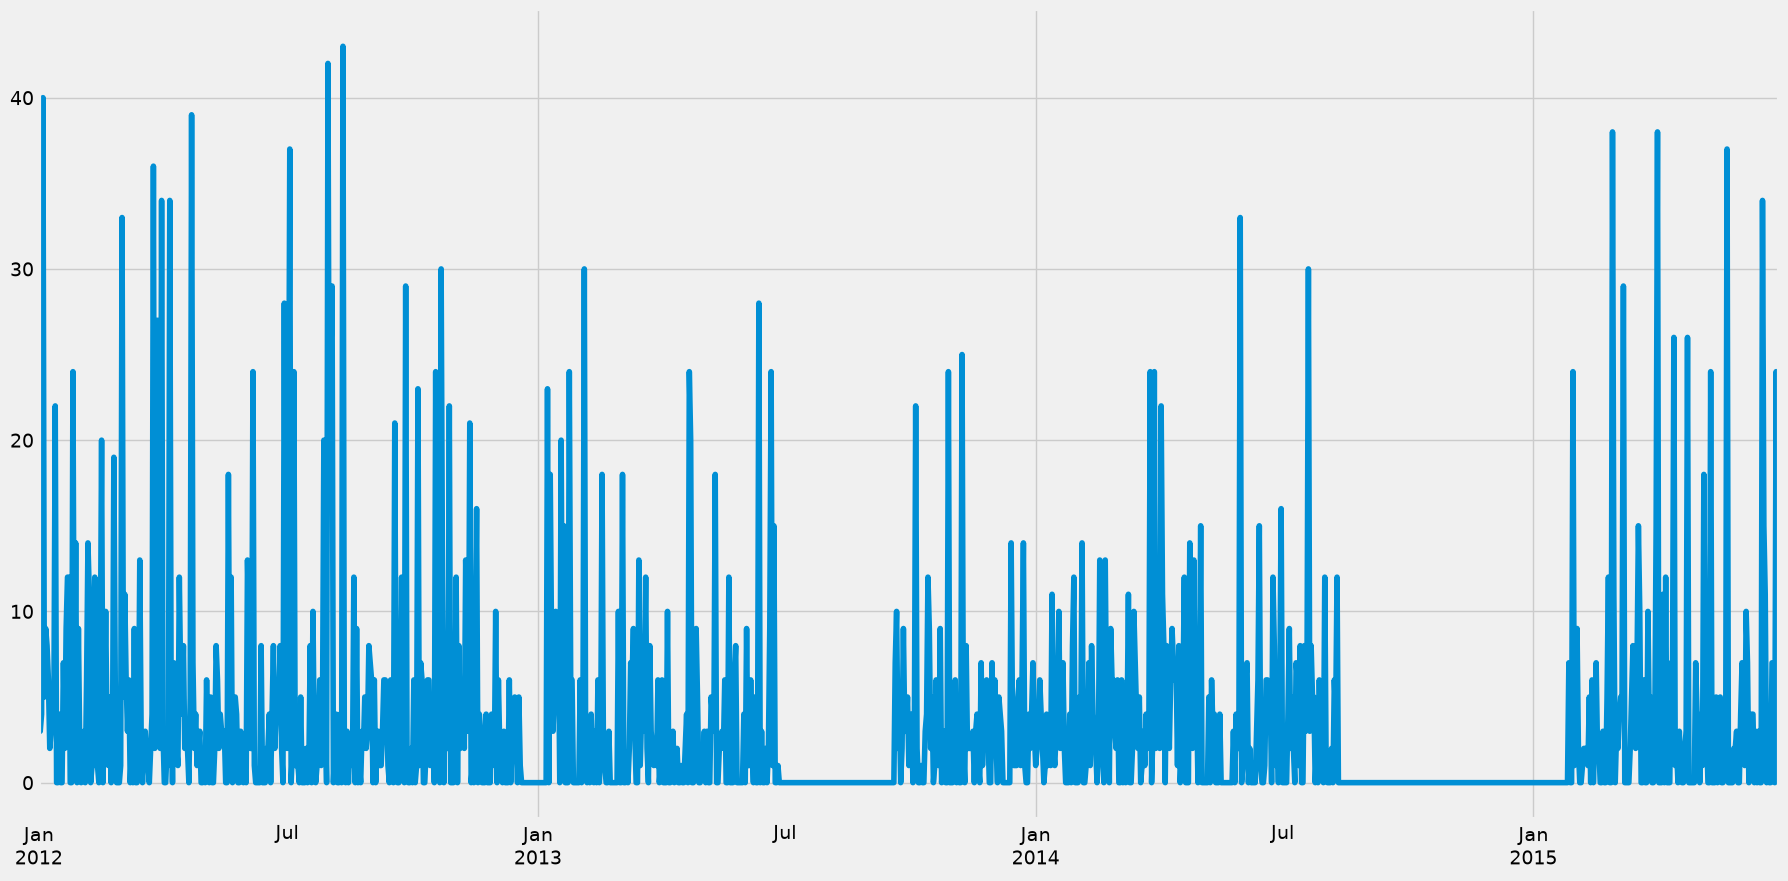

In [13]:
df = xdat.loc[(xdat.item_id == 'HOBBIES_1_288') & (xdat.store_id == 'CA_1')][['date', 'sales']].copy()
df = df.loc[(df.date >= '2012-01-01') & (df.date <= '2015-06-30')]
df.set_index('date').sales.plot(xlabel='')
print()

Before any modeling, we always look at the raw data. We subset a single product x store combination: item `HOBBIES_1_288` in store `CA_1` , restrict it to a 3.5 year window, set the date as the index, and call the pandas `.plot()` accessor on the sales Series (the trailing `print()` suppresses the matplotlib object repr).

In [14]:
panel_one = df.rename(columns={'date': 'ds', 'sales': 'y'}).assign(unique_id='HOBBIES_1_288_CA_1')
classify_intermittency(panel_one)

,unique_id,adi,cv2,category
0,HOBBIES_1_288_CA_1,1.91,1.25,lumpy


We run our classifier on this single series (renaming columns to the `unique_id` / `ds` / `y` convention the helper expects — the same convention used by the `statsforecast` ecosystem and the TSB-HB reference code). The result: an ADI above 1.32 => demand occurs only every few days, so the series is in the bottom row of the classification matrix. 

Depending on the size variability it lands in the **intermittent** or **lumpy** cell; either way, this is exactly the demand pattern the Croston family was designed for, and in the TSB-HB paper's Online Retail panel these two categories together cover over 97% of all SKUs. 

# Croston family